In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
type(df["TotalCharges"].sum())

str

In [13]:
#converting it to float 
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors = 'coerce').fillna(0)
#converting churn into binary 1s and 0s 
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [14]:
X =  pd.get_dummies(df[['tenure', 'MonthlyCharges', 'Contract']], drop_first=True) #features
y = df['Churn'] #target variable we are predicting

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
#train on 80% of the data and test on the remaining 20%

In [16]:
#building the decision tree 
model = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
model.fit(X_train, y_train)
# model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

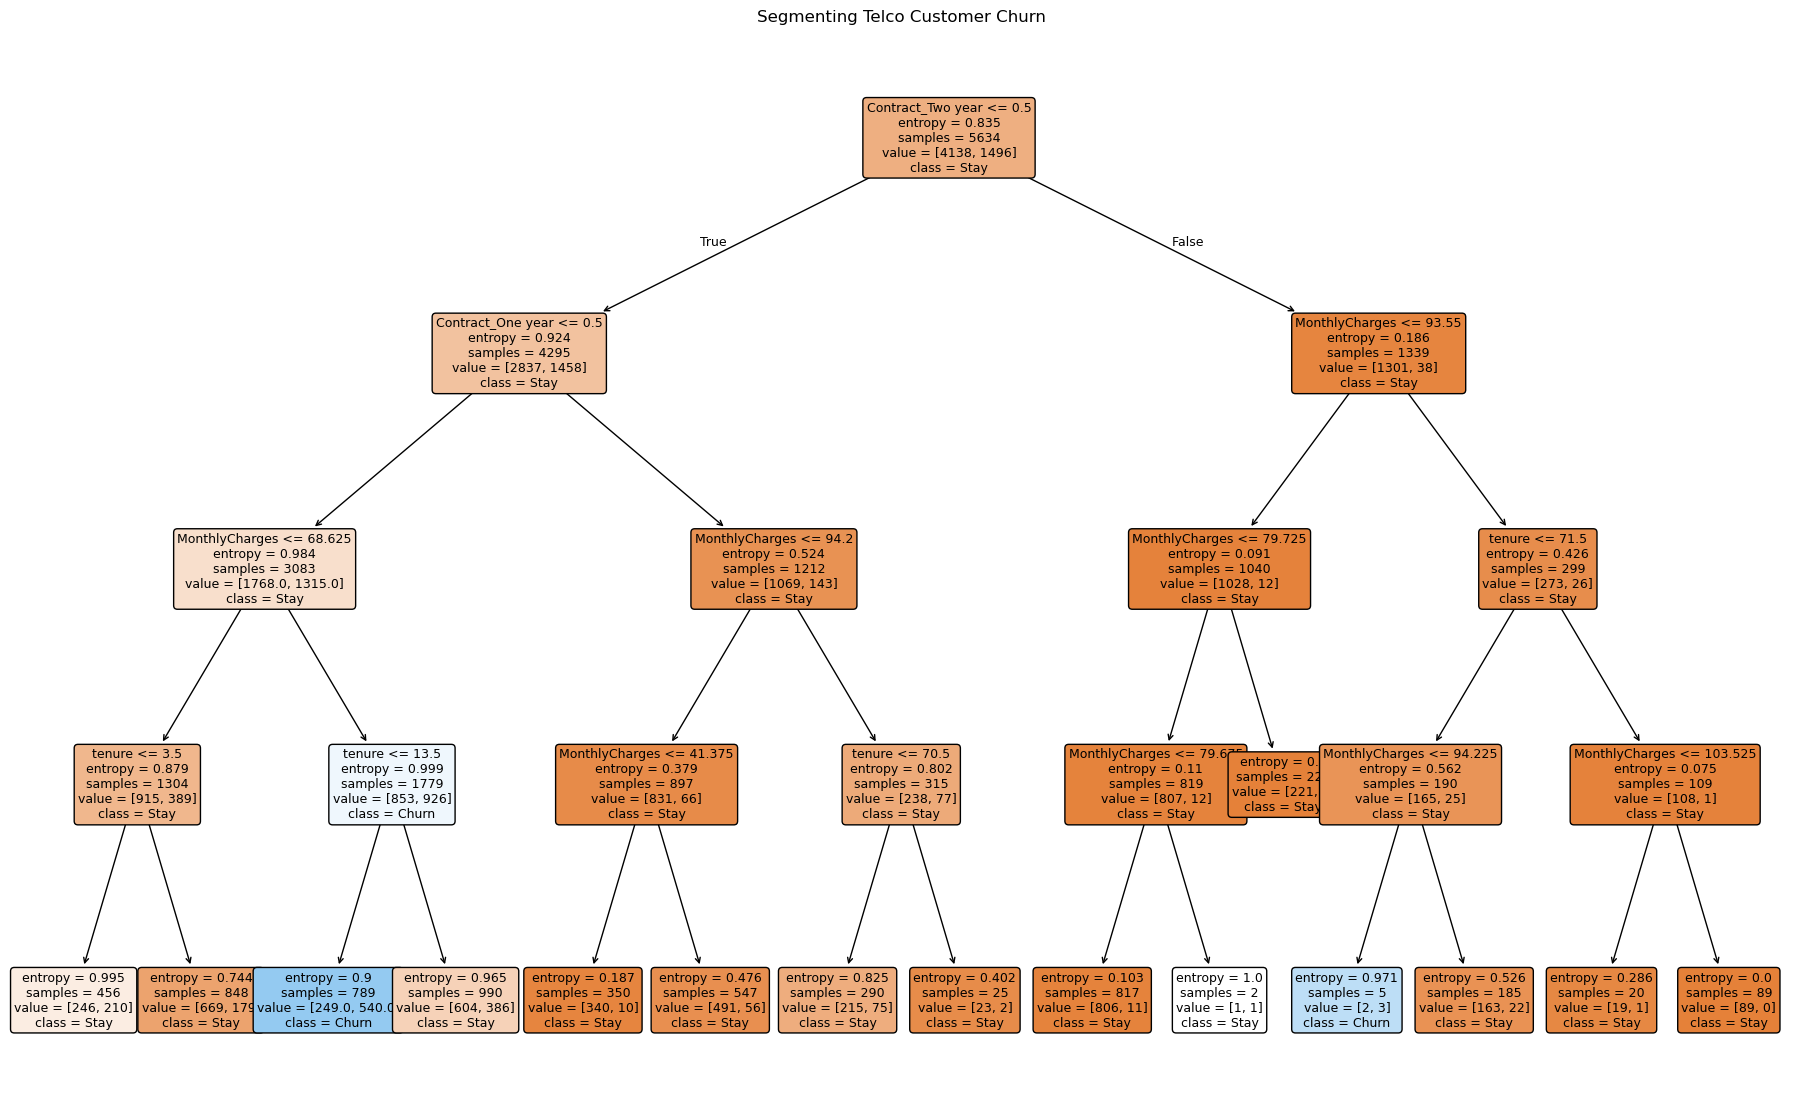

In [18]:
plt.figure(figsize=(23,14))
plot_tree(model, feature_names=X.columns, class_names=['Stay', 'Churn'], filled=True, rounded=True, fontsize=9)
plt.title("Segmenting Telco Customer Churn")
plt.show()

In [21]:
# Checking with feature is the most important
importances = model.feature_importances_
feature_names = X.columns

In [20]:
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df

,Feature,Importance
3,Contract_Two year,0.409136
2,Contract_One year,0.253501
1,MonthlyCharges,0.177023
0,tenure,0.160340


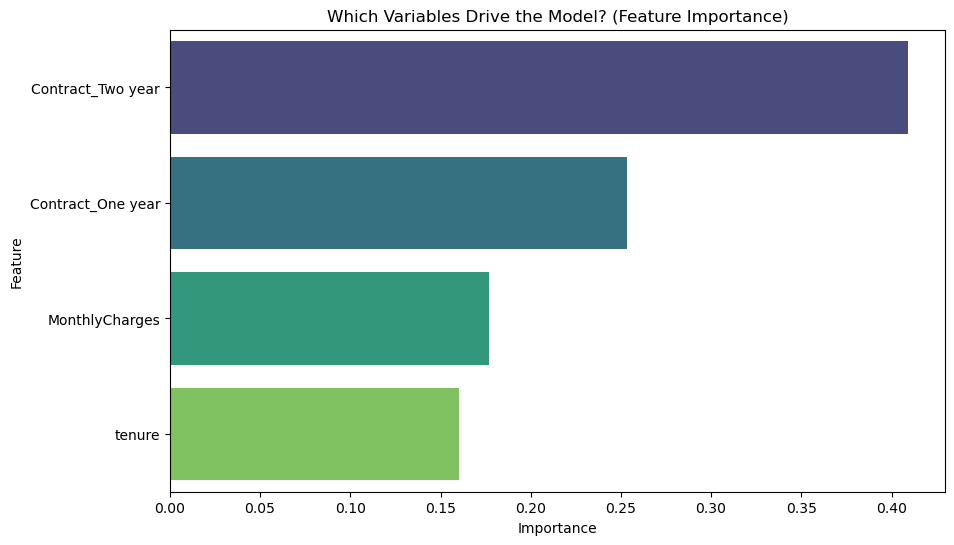

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', legend = False, palette = 'viridis')
plt.title("Which Variables Drive the Model? (Feature Importance)")
plt.show()

In [30]:
#prediction on test data 
y_pred = model.predict(X_test)

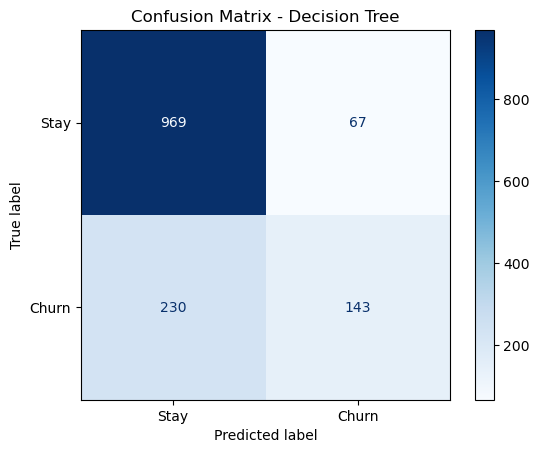

In [32]:
#confusion matrix 
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [33]:
Accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Stay', 'Churn'])
print(f"Accuracy: {Accuracy} ")
print("Classification report: ")
print(report)

Accuracy: 0.7892122072391767 
Classification report: 
              precision    recall  f1-score   support

        Stay       0.81      0.94      0.87      1036
       Churn       0.68      0.38      0.49       373

    accuracy                           0.79      1409
   macro avg       0.74      0.66      0.68      1409
weighted avg       0.77      0.79      0.77      1409

